# 🚗 SFMTA Parking Citations Analysis
**Date Range:** January 1, 2016 – March 3, 2026  
This notebook imports, explores, cleans, and visualizes the SFMTA parking citations dataset.

## 1. Install & Import Dependencies

In [1]:
# Install required libraries (run once)
# !pip install pandas numpy matplotlib seaborn folium geopandas missingno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap, MarkerCluster
import missingno as msno
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


## 2. Load the Dataset
Update the `FILE_PATH` variable below to point to your local SFMTA CSV file. 

In [ ]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
FILE_PATH = r'C:\Users\jimmy\Desktop\CS122\ZeninClan-sf-parking-citation-analysis\data\SFMTA_-_Parking_Citations_&_Fines_20260303.csv'
DATE_COL  = 'Citation Issued DateTime'
LAT_COL   = 'Latitude'
LON_COL   = 'Longitude'
# ─────────────────────────────────────────────────────────────────────────────

print(f'Loading dataset from: {FILE_PATH}')

df = pd.read_csv(
    FILE_PATH,
    low_memory=False,
    parse_dates=[DATE_COL]
)

print(f'✅ Loaded {len(df):,} rows and {df.shape[1]} columns.')

Loading dataset from: C:\Users\jimmy\Desktop\CS122\ZeninClan-sf-parking-citation-analysis\data\SFMTA_-_Parking_Citations_&_Fines_20260303.csv
✅ Loaded 12,396,015 rows and 14 columns.


## 3. Dataset Exploration

In [ ]:
# Print shape
print(f'Shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns\n')

# Column name overview
print('=== Columns & Data Types ===')
print(df.dtypes.to_string())

Shape: 12,396,015 rows  ×  14 columns

=== Columns & Data Types ===
Citation Number                        str
Citation Issued DateTime    datetime64[us]
Violation                              str
Violation Description                  str
Citation Location                      str
Vehicle Plate State                    str
Vehicle Plate                          str
Fine Amount                            str
Date Added                             str
geom                                   str
supervisor_district                float64
analysis_neighborhood                  str
Latitude                               str
Longitude                              str


In [16]:
# First 5 rows
df.head()

,Citation Number,Citation Issued DateTime,Violation,Violation Description,Citation Location,Vehicle Plate State,Vehicle Plate,Fine Amount,Date Added,geom,supervisor_district,analysis_neighborhood,Latitude,Longitude
0,PD27111103,2016-01-01 00:31:00,TRC7.2.42,RESTRICTED,517 BROADWAY,NY,HAL1777,$91,2016 Jan 01 12:00:00 AM,POINT (-122.40586398299996 37.797745991000056),3.00,North Beach,POINT(-122.40586398299996 37.797745991000056),POINT(-122.40586398299996 37.797745991000056)
1,PD28681155,2016-01-01 01:00:00,PK7.03U,NO PERMIT,200 MARINA BLVD,CA,6PTZ366,$23,2016 Jan 01 12:00:00 AM,POINT (-122.43565265499996 37.80626246600008),2.00,Marina,POINT(-122.43565265499996 37.80626246600008),POINT(-122.43565265499996 37.80626246600008)
2,PD28681170,2016-01-01 01:03:00,PK6.01H,MAR GRN PK,200 MARINA BLVD,NaN,NaN,$23,2016 Jan 01 12:00:00 AM,POINT (-122.43565265499996 37.80626246600008),2.00,Marina,POINT(-122.43565265499996 37.80626246600008),POINT(-122.43565265499996 37.80626246600008)
3,PD28681166,2016-01-01 01:05:00,PK6.01H,MAR GRN PK,200 MARINA BLVD,CA,7DTT877,$23,2016 Jan 01 12:00:00 AM,POINT (-122.43565265499996 37.80626246600008),2.00,Marina,POINT(-122.43565265499996 37.80626246600008),POINT(-122.43565265499996 37.80626246600008)
4,PD28455136,2016-01-01 01:15:00,V5204A,REG TABS,517 YORK ST,CA,7HEG637,$121,2020 Nov 26 12:00:00 AM,POINT (-122.40892999899995 37.76269501000007),9.00,Mission,POINT(-122.40892999899995 37.76269501000007),POINT(-122.40892999899995 37.76269501000007)


In [17]:
# Statistical summary for numeric columns
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Citation Number,12396015,12396015,PD27111103,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Citation Issued DateTime,12396015,NaN,NaN,NaN,2021-02-10 13:23:01.859756,2016-01-01 00:31:00,2018-04-30 04:20:30,2021-03-05 10:04:00,2023-12-15 06:27:00,2026-02-26 19:53:00,NaN
Violation,12394966,217,TRC7.2.22,5266621,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Violation Description,12394965,203,STR CLEAN,5266621,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Citation Location,12362287,1056637,50 DRUMM ST,14709,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Plate State,12033288,130,CA,11467520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Plate,11990299,3240370,70358W1,1235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fine Amount,12396015,465,$108,1299494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date Added,12396015,2782,2020 Apr 30 12:00:00 AM,853804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geom,4866819,422509,POINT (-122.41963999999996 37.777120000000025),53032,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Date range check
print(f"Earliest citation : {df[DATE_COL].min()}")
print(f"Latest  citation  : {df[DATE_COL].max()}")
print(f"Date range span   : {(df[DATE_COL].max() - df[DATE_COL].min()).days:,} days")

Earliest citation : 2016-01-01 00:31:00
Latest  citation  : 2026-02-26 19:53:00
Date range span   : 3,709 days


## 4. Missing Data Analysis

In [19]:
# Missing value counts and percentages
missing = pd.DataFrame({
    'Missing Count' : df.isnull().sum(),
    'Missing %'     : (df.isnull().mean() * 100).round(2)
}).sort_values('Missing %', ascending=False)

missing[missing['Missing Count'] > 0]

,Missing Count,Missing %
supervisor_district,7637081,61.61
analysis_neighborhood,7636815,61.61
Latitude,7529196,60.74
geom,7529196,60.74
Longitude,7529196,60.74
Vehicle Plate,405716,3.27
Vehicle Plate State,362727,2.93
Citation Location,33728,0.27
Violation,1049,0.01
Violation Description,1050,0.01


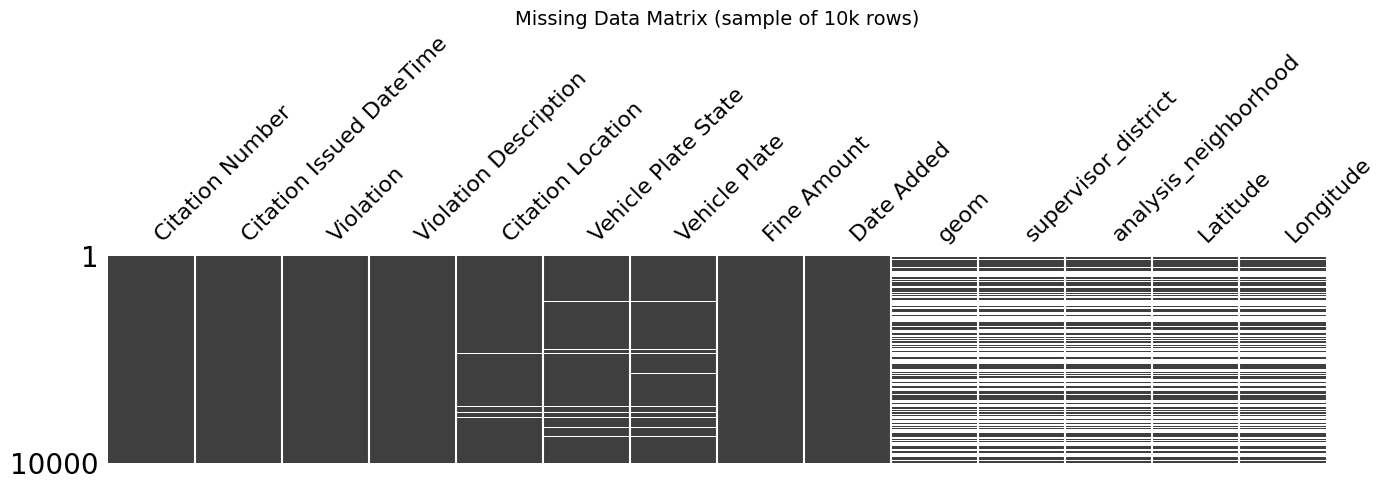

In [20]:
# Visual matrix of missing data
fig, ax = plt.subplots(figsize=(14, 5))
msno.matrix(df.sample(min(10_000, len(df)), random_state=42), ax=ax, sparkline=False)
ax.set_title('Missing Data Matrix (sample of 10k rows)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Data Cleaning


In [28]:
# ── Parse coordinates from geom column ───────────────────────────────────────
df[['LON_parsed', 'LAT_parsed']] = (
    df['geom']
    .str.extract(r'POINT \(([^\s]+) ([^\s]+)\)')
    .astype(float)
)
LAT_COL = 'LAT_parsed'
LON_COL = 'LON_parsed'

# ── Build geo subset: only rows with valid SF coordinates ─────────────────────
df_geo = df.dropna(subset=[LAT_COL, LON_COL]).copy()
df_geo = df_geo[
    df_geo[LAT_COL].between(37.6, 37.9) &
    df_geo[LON_COL].between(-122.6, -122.3)
]

# ── Derive time features (applied to full dataset) ───────────────────────────
df['year']        = df[DATE_COL].dt.year
df['month']       = df[DATE_COL].dt.month
df['day_of_week'] = df[DATE_COL].dt.day_name()
df['hour']        = df[DATE_COL].dt.hour

print('=== Cleaning Summary ===')
print(f'Full dataset (df)              : {len(df):>12,} rows — used for time/violation analysis')
print(f'Geo subset   (df_geo)          : {len(df_geo):>12,} rows — used for map visualizations')
print(f'Dropped (no valid coordinates) : {len(df) - len(df_geo):>12,} rows ({(1 - len(df_geo)/len(df))*100:.1f}%)')
print('✅ Cleaning complete.')

=== Cleaning Summary ===
Full dataset (df)              :   12,396,015 rows — used for time/violation analysis
Geo subset   (df_geo)          :    4,760,296 rows — used for map visualizations
Dropped (no valid coordinates) :    7,635,719 rows (61.6%)
✅ Cleaning complete.


## 6. Exploratory Analysis

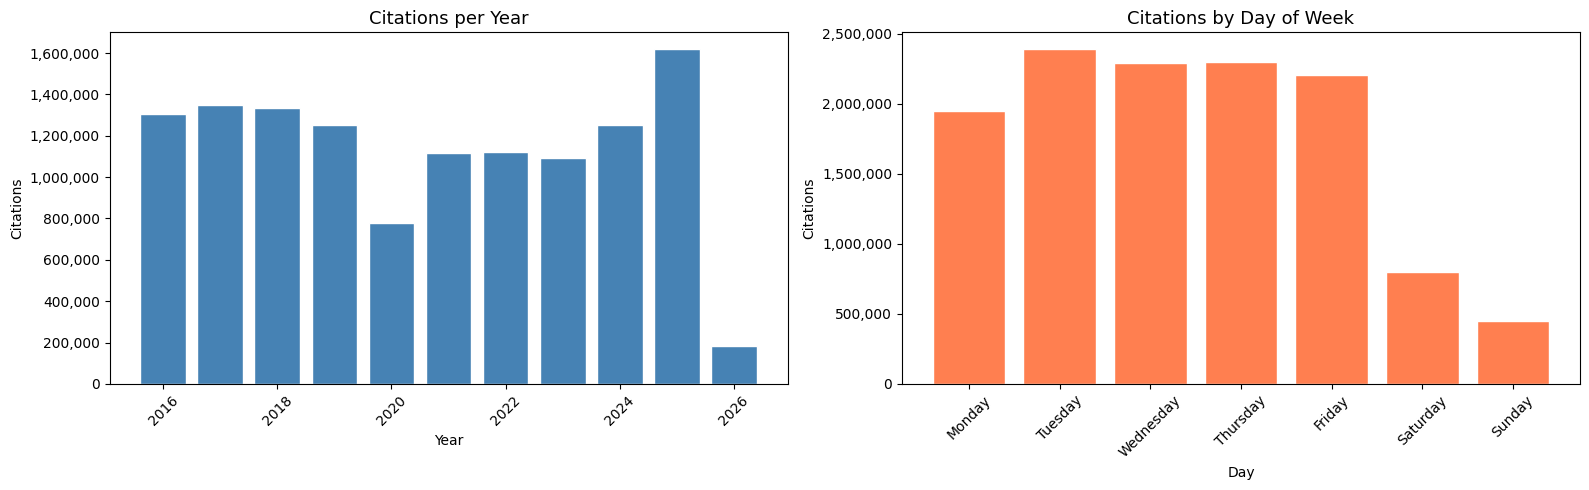

In [29]:
# Citations per year
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

yearly = df.groupby('year').size().reset_index(name='citations')
axes[0].bar(yearly['year'], yearly['citations'], color='steelblue', edgecolor='white')
axes[0].set_title('Citations per Year', fontsize=13)
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Citations')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=45)

# Citations by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df['day_of_week'].value_counts().reindex(dow_order)
axes[1].bar(dow.index, dow.values, color='coral', edgecolor='white')
axes[1].set_title('Citations by Day of Week', fontsize=13)
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Citations')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

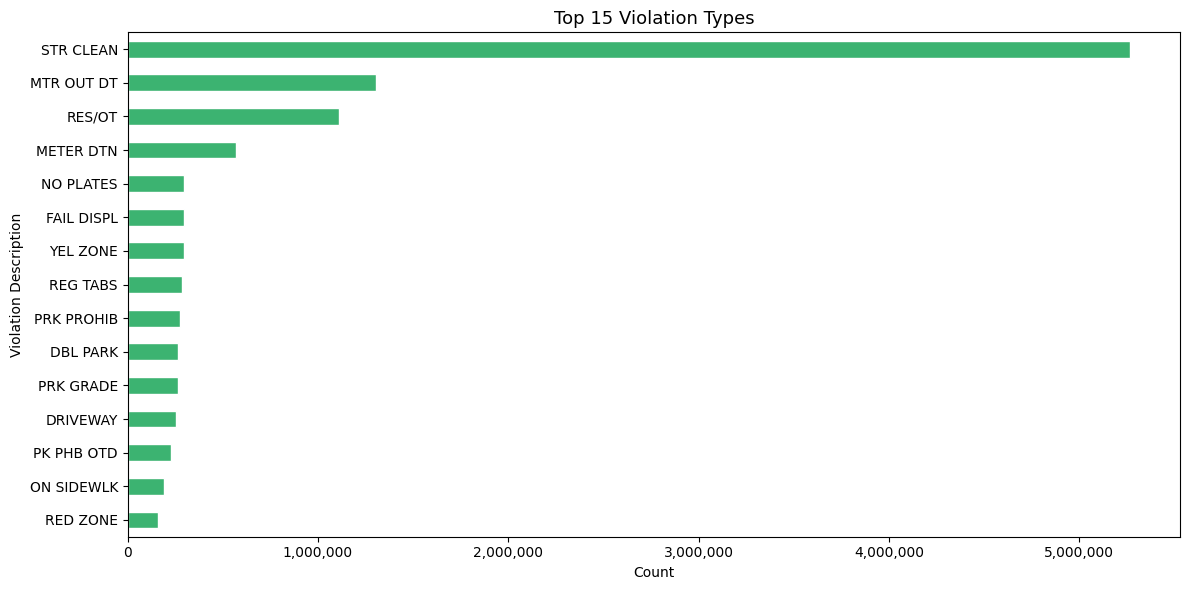

In [ ]:
# Top 15 violation types
if 'Violation Description' in df.columns:
    top_violations = df['Violation Description'].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(12, 6))
    top_violations.sort_values().plot(kind='barh', ax=ax, color='mediumseagreen', edgecolor='white')
    ax.set_title('Top 15 Violation Types', fontsize=13)
    ax.set_xlabel('Count')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()
else:
    print('Column "Violation Description" not found — update column name as needed.')

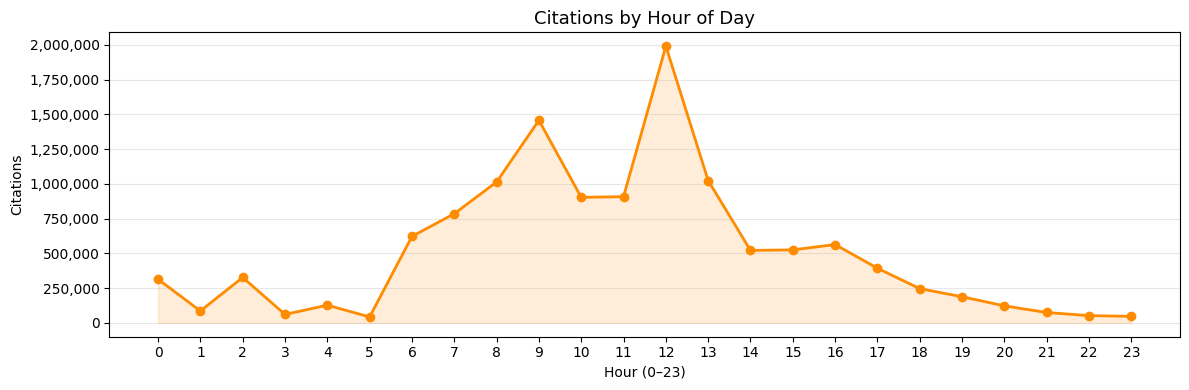

In [31]:
# Citations by hour of day
hourly = df.groupby('hour').size()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly.index, hourly.values, marker='o', color='darkorange', linewidth=2)
ax.fill_between(hourly.index, hourly.values, alpha=0.15, color='darkorange')
ax.set_title('Citations by Hour of Day', fontsize=13)
ax.set_xlabel('Hour (0–23)'); ax.set_ylabel('Citations')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Map Visualization — Citation Hotspots

We use **Folium** to render an interactive heatmap and a clustered marker map directly in the notebook.

In [ ]:
# ── Sample for performance (adjust sample_size as needed) ────────────────────
SAMPLE_SIZE = 100_000
geo_sample = df_geo.sample(min(SAMPLE_SIZE, len(df_geo)), random_state=42)

heat_data = geo_sample[[LAT_COL, LON_COL]].dropna().values.tolist()
print(f'Using {len(heat_data):,} points for the heatmap.')

Using 100,000 points for the heatmap.


In [35]:
SF_CENTER = [37.7749, -122.4194]

heatmap = folium.Map(
    location=SF_CENTER,
    zoom_start=13,
    tiles='CartoDB dark_matter'
)

HeatMap(
    heat_data,
    radius=8,
    blur=6,
    min_opacity=0.2,
    max_zoom=13,
    gradient={
        0.0: '#0000ff',   # blue    — very low
        0.2: '#00ffff',   # cyan    — low
        0.4: '#00ff00',   # green   — moderate
        0.6: '#ffff00',   # yellow  — high
        0.8: '#ff8000',   # orange  — very high
        1.0: '#ff0000',   # red     — hotspot
    }
).add_to(heatmap)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_html = '''
<div style="
    position: fixed;
    bottom: 40px; right: 40px;
    background-color: rgba(0,0,0,0.75);
    color: white;
    padding: 14px 18px;
    border-radius: 8px;
    font-family: Arial, sans-serif;
    font-size: 13px;
    z-index: 9999;
    line-height: 1.8;
">
    <b>Citation Density</b><br>
    <span style="color:#ff0000;">&#9632;</span> Hotspot (highest)<br>
    <span style="color:#ff8000;">&#9632;</span> Very High<br>
    <span style="color:#ffff00;">&#9632;</span> High<br>
    <span style="color:#00ff00;">&#9632;</span> Moderate<br>
    <span style="color:#00ffff;">&#9632;</span> Low<br>
    <span style="color:#0000ff;">&#9632;</span> Very Low<br>
    <br>
    <small>Sample: 100,000 citations</small>
</div>
'''
heatmap.get_root().html.add_child(folium.Element(legend_html))

heatmap.save('sfmta_heatmap.html')
print('✅ Heatmap saved to sfmta_heatmap.html')
heatmap

✅ Heatmap saved to sfmta_heatmap.html


In [ ]:
# ── 7b. Top-50 street hotspot map (clustered markers) ────────────────────────
if 'Citation Location' in df_geo.columns:
    top_streets = (
        df_geo.groupby('Citation Location')
        .agg(count=(LAT_COL, 'count'),
             lat  =(LAT_COL, 'median'),
             lon  =(LON_COL, 'median'))
        .sort_values('count', ascending=False)
        .head(50)
        .reset_index()
    )

    cluster_map = folium.Map(location=SF_CENTER, zoom_start=13, tiles='CartoDB positron')
    marker_cluster = MarkerCluster(name='Top 50 Hotspot Streets').add_to(cluster_map)

    for _, row in top_streets.iterrows():
        folium.Marker(
            location=[row['lat'], row['lon']],
            popup=folium.Popup(
                f"<b>{row['Citation Location']}</b><br>Citations: {row['count']:,}",
                max_width=200
            ),
            icon=folium.Icon(color='red', icon='car', prefix='fa')
        ).add_to(marker_cluster)

    folium.LayerControl().add_to(cluster_map)
    cluster_map.save('sfmta_top_streets.html')
    print('✅ Cluster map saved to sfmta_top_streets.html')
    cluster_map
else:
    print('Column "Citation Location" not found — update column name as needed.')

In [ ]:
# ── 7c. Choropleth by citation density per grid cell (optional hex-bin) ───────
# Bin coordinates into a grid and count citations per cell
GRID_SIZE = 0.002  # ~200 m grid

df_geo['lat_bin'] = (df_geo[LAT_COL] / GRID_SIZE).round() * GRID_SIZE
df_geo['lon_bin'] = (df_geo[LON_COL] / GRID_SIZE).round() * GRID_SIZE

grid_counts = (
    df_geo.groupby(['lat_bin', 'lon_bin'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print(f'Grid cells with citations: {len(grid_counts):,}')
print('\nTop 10 hotspot grid cells:')
grid_counts.head(10)

## 8. Summary Statistics

In [ ]:
print('=' * 50)
print('SFMTA CITATIONS — SUMMARY')
print('=' * 50)
print(f"Total citations (cleaned)   : {len(df):>12,}")
print(f"Citations with GPS coords   : {len(df_geo):>12,}")
print(f"Date range                  : {df[DATE_COL].min().date()} → {df[DATE_COL].max().date()}")

if 'Fine Amount' in df.columns:
    df['Fine Amount'] = pd.to_numeric(df['Fine Amount'], errors='coerce')
    print(f"Total fines issued          : ${df['Fine Amount'].sum():>14,.0f}")
    print(f"Avg fine per citation       : ${df['Fine Amount'].mean():>14,.2f}")

if 'Citation Location' in df.columns:
    top_street = df['Citation Location'].value_counts().idxmax()
    top_count  = df['Citation Location'].value_counts().max()
    print(f"Most cited street           : {top_street} ({top_count:,} citations)")

top_dow = df['day_of_week'].value_counts().idxmax()
print(f"Busiest day of week         : {top_dow}")
print(f"Busiest hour of day         : {int(df['hour'].value_counts().idxmax())}:00")
print('=' * 50)